# 火炎の位置を取得する

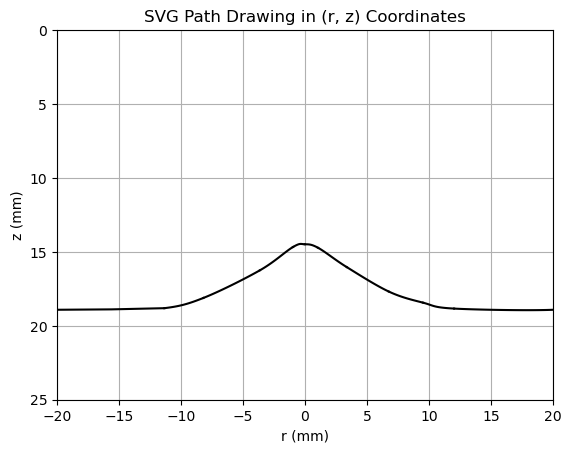

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# xとyの範囲
x_min, x_max = -20, 20
y_min, y_max = 0, 25

# SVGパスデータ
start_point = (826.5, 1741.72)

# SVGのx範囲（推定）
svg_x_min = 826.5
svg_x_max = 1959.5

# SVGのy範囲（修正後）
svg_y_min = 1201.5
svg_y_max = svg_y_min + 714  # = 1915.5

# 線形変換関数
def transform_x(x_svg):
    return (x_svg - (svg_x_min + svg_x_max) / 2) / ((svg_x_max - svg_x_min) / 2) * 20

def transform_y(y_svg):
    return (y_svg - svg_y_min) / (svg_y_max - svg_y_min) * 25

# Pathデータ（MoveTo, LineTo）
svg_points = [
    (826.5, 1741.72),
    (950.946, 1740.96),
    (1071.58, 1738.67)
]

# Cubic Bézier
c_points = [
    (1106.57, 1734.98, 1124.51, 1731.05, 1160.9, 1718.85),
    (1197.3, 1706.65, 1255.83, 1681.87, 1289.93, 1665.47),
    (1324.03, 1649.08, 1348.46, 1628.87, 1365.51, 1620.49),
    (1382.57, 1612.1, 1382.69, 1614.89, 1392.24, 1615.15),
    (1401.78, 1615.4, 1406.74, 1614.64, 1422.78, 1622.01),
    (1438.81, 1629.38, 1461.46, 1645.27, 1488.43, 1659.37),
    (1515.41, 1673.48, 1555.62, 1695.21, 1584.63, 1706.65),
    (1613.64, 1718.08, 1637.69, 1722.53, 1662.51, 1728),
    (1687.32, 1733.46, 1684.01, 1737.14, 1733.51, 1739.43),
    (1783.01, 1741.72, 1908.35, 1743.63, 1959.5, 1741.72)
]

# プロット
# plt.figure(figsize=(8,8))

# x, yデータ格納用
x_list = []
y_list = []

# MoveTo, LineTo部分
for x_svg, y_svg in svg_points:
    x_trans = transform_x(x_svg)
    y_trans = transform_y(y_svg)
    x_list.append(x_trans)
    y_list.append(y_trans)
plt.plot(x_list, y_list, 'k-')

# Bézier部分
last_point = svg_points[-1]
for (x1, y1, x2, y2, x, y) in c_points:
    t = np.linspace(0,1,50)
    P0 = np.array([transform_x(last_point[0]), transform_y(last_point[1])])
    P1 = np.array([transform_x(x1), transform_y(y1)])
    P2 = np.array([transform_x(x2), transform_y(y2)])
    P3 = np.array([transform_x(x), transform_y(y)])
    B = (1-t)[:,None]**3 * P0 + \
        3*(1-t)[:,None]**2 * t[:,None] * P1 + \
        3*(1-t)[:,None] * t[:,None]**2 * P2 + \
        t[:,None]**3 * P3
    x_list.extend(B[:,0])
    y_list.extend(B[:,1])
    plt.plot(B[:,0], B[:,1], 'k-')
    last_point = (x, y)

# 軸設定
plt.xlim(x_min, x_max)
plt.ylim(y_max, y_min)  # y軸逆向き
plt.xlabel("r (mm)")
plt.ylabel("z (mm)")
plt.title("SVG Path Drawing in (r, z) Coordinates")
plt.grid(True)
plt.show()

# NumPy配列に変換
x_array = np.array(x_list)
y_array = np.array(y_list)

# # 保存（例：npzファイル）
# np.savez("svg_path_data.npz", x=x_array, y=y_array)

# 保存した内容の確認（読み込み例）
# data = np.load("svg_path_data.npz")
# x_loaded = data["x"]
# y_loaded = data["y"]


ガウシアンでフィッティング

Fit parameters: A = -4.195, sigma = 4.054, C = 18.812


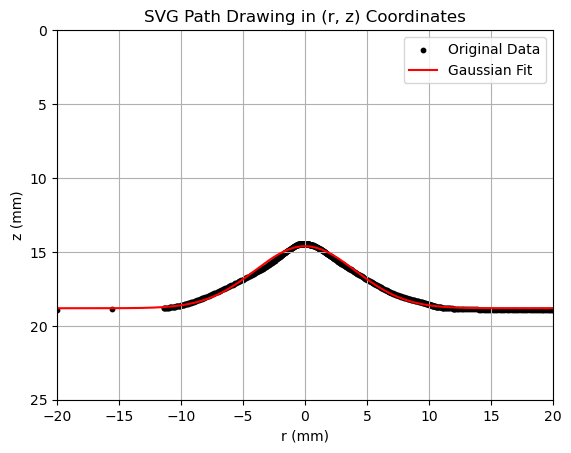

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# データ読み込み
# data = np.load("svg_path_data.npz")
r = x_array
z = y_array

# 左右対称なので |r| に変換
r_sym = np.abs(r)

# 対称関数：ガウス
def gaussian(r, A, sigma, C):
    return A * np.exp(-r**2/(2*sigma**2)) + C

# 初期値推定
A_guess = np.max(z) - np.min(z)
sigma_guess = 5
C_guess = np.min(z)

# フィッティング
params, covariance = curve_fit(gaussian, r_sym, z, p0=[A_guess, sigma_guess, C_guess])

A_fit, sigma_fit, C_fit = params
print(f"Fit parameters: A = {A_fit:.3f}, sigma = {sigma_fit:.3f}, C = {C_fit:.3f}")

# フィッティング曲線
r_fit = np.linspace(-20, 20, 200)
z_fit = gaussian(np.abs(r_fit), A_fit, sigma_fit, C_fit)

# プロット
# plt.figure(figsize=(8,6))
plt.scatter(r, z, label="Original Data", color="black", s=10)
plt.plot(r_fit, z_fit, label="Gaussian Fit", color="red")
# plt.xlabel("r (mm)")
# plt.ylabel("z (mm)")
plt.legend()
# plt.grid(True)
# plt.show()

# 軸設定
plt.xlim(x_min, x_max)
plt.ylim(y_max, y_min)  # y軸逆向き
plt.xlabel("r (mm)")
plt.ylabel("z (mm)")
plt.title("SVG Path Drawing in (r, z) Coordinates")
plt.grid(True)
plt.show()

ギャップ長さで正規化する

(0.0, 1.0)

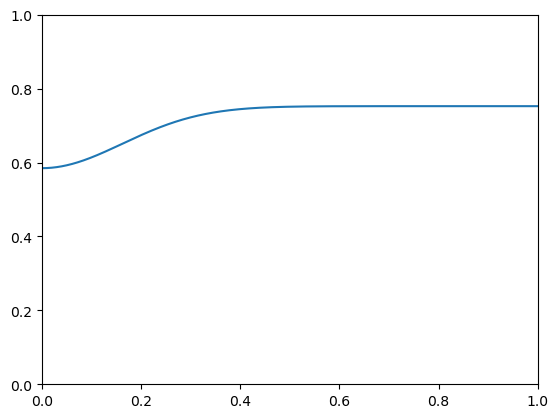

In [35]:
x_norm = np.linspace(0, 1, 1000)

y_norm = (-4.195 * np.exp(-(x_norm*25.0)**2/(2*4.054**2)) + 18.812)/25.0
plt.plot(x_norm, y_norm)

# 軸設定
plt.xlim(0, 1)
plt.ylim(0, 1)
# plt.xlabel("r (mm)")
# plt.ylabel("z (mm)")
# plt.title("SVG Path Drawing in (r, z) Coordinates")
# plt.grid(True)
# plt.show()